In [3]:
import pandas as pd


df = pd.read_csv("dataset/IMDB Dataset.csv")

df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [4]:
df.shape

(50000, 2)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB


In [6]:
df.columns

Index(['review', 'sentiment'], dtype='object')

In [7]:
df["sentiment"].value_counts()

sentiment
positive    25000
negative    25000
Name: count, dtype: int64

NameError: name 'plt' is not defined

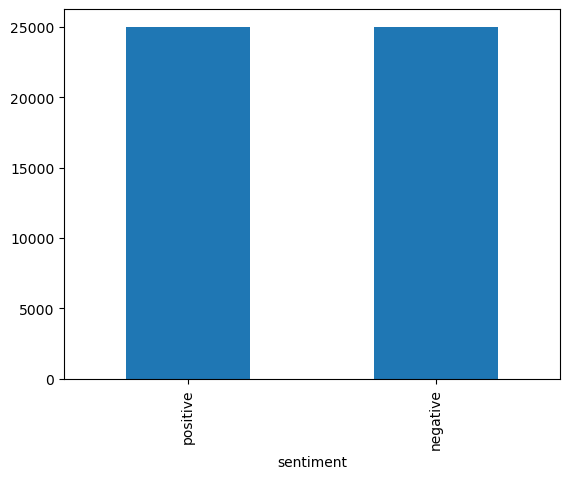

In [10]:
df["sentiment"].value_counts().plot(kind="bar")

plt.title("Distribution of Sentiments")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.show()

In [11]:
df.duplicated().sum()

np.int64(418)

In [12]:
df["review"].duplicated().sum()

np.int64(418)

In [13]:
df["review_length"] = df["review"].apply(len)

df["review_length"].describe()

count    50000.000000
mean      1309.431020
std        989.728014
min         32.000000
25%        699.000000
50%        970.000000
75%       1590.250000
max      13704.000000
Name: review_length, dtype: float64

In [14]:
print("Shortest Review:")
print(df.loc[df["review_length"].idxmin(), "review"])

print("\nLongest Review:")
print(df.loc[df["review_length"].idxmax(), "review"])

Shortest Review:
Read the book, forget the movie!

Longest Review:
Match 1: Tag Team Table Match Bubba Ray and Spike Dudley vs Eddie Guerrero and Chris Benoit Bubba Ray and Spike Dudley started things off with a Tag Team Table Match against Eddie Guerrero and Chris Benoit. According to the rules of the match, both opponents have to go through tables in order to get the win. Benoit and Guerrero heated up early on by taking turns hammering first Spike and then Bubba Ray. A German suplex by Benoit to Bubba took the wind out of the Dudley brother. Spike tried to help his brother, but the referee restrained him while Benoit and Guerrero ganged up on him in the corner. With Benoit stomping away on Bubba, Guerrero set up a table outside. Spike dashed into the ring and somersaulted over the top rope onto Guerrero on the outside! After recovering and taking care of Spike, Guerrero slipped a table into the ring and helped the Wolverine set it up. The tandem then set up for a double superplex fro

In [22]:
import re

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

In [23]:
import nltk

nltk.download("stopwords")
nltk.download("wordnet")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Shivam\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Shivam\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [24]:
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

In [25]:
word = "movies"

print(lemmatizer.lemmatize(word))

movie


In [35]:
def clean_text(text):

    text = text.lower()

    text = re.sub(r"<.*?>", " ", text)


    text = re.sub(r"[^a-zA-Z\s]", " ", text)

    text = re.sub(r"\s+", " ", text).strip()

    words = text.split()

    words = [
         lemmatizer.lemmatize(word)

         for word in words
         if word not in stop_words

    ]
    return " ".join(words)

In [36]:
print("Original Review:")
print(df["review"].iloc[0])


#we can see here that diffrence between original and cleaned
print("\nCleaned Review:")
print(clean_text(df["review"].iloc[0]))

Original Review:
One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.<br /><br />I would say the main appeal of the show 

In [37]:
df["cleaned_review"] = df["review"].apply(clean_text)

updated data

In [38]:
df[["review", "cleaned_review", "sentiment"]].head()

,review,cleaned_review,sentiment
0,One of the other reviewers has mentioned that ...,one reviewer mentioned watching oz episode hoo...,positive
1,A wonderful little production. <br /><br />The...,wonderful little production filming technique ...,positive
2,I thought this was a wonderful way to spend ti...,thought wonderful way spend time hot summer we...,positive
3,Basically there's a family where a little boy ...,basically family little boy jake think zombie ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",petter mattei love time money visually stunnin...,positive


In [39]:
(df["cleaned_review"].str.strip() == "").sum()

np.int64(0)

In [40]:
df.shape

(50000, 4)

In [41]:
df.columns

Index(['review', 'sentiment', 'review_length', 'cleaned_review'], dtype='object')